# Inferential statistics — Portugal carbon-majors heat-loss attribution

This notebook generates the statistical tests reported in Section 3.5 of the AVCAD final report. It tests the two hypotheses the report states explicitly:

- **H1** — do apportioned losses differ by entity type (investor-owned / state-owned / nation-state)?
- **H2** — do apportioned losses differ between the two events (E1: April 2023, E2: July 2022)?

Both are tested on the actual outcome variable of the project — apportioned loss in EUR (`loss_eur_central`) — rather than on raw cumulative emissions, since loss is what the report's claims are about.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, wilcoxon

df = pd.read_csv("data/processed/portugal_event_losses_by_carbon_major.csv")
df.head()

,event_id,event_name,entity,entity_type,pct_global_CO2_1854_2022,loss_eur_low,loss_eur_central,loss_eur_high
0,E1,April 2023 Iberian heatwave,China (Coal),nation_state,14.01,2.394459e+06,2.993074e+06,4.190303e+06
1,E1,April 2023 Iberian heatwave,Former Soviet Union,nation_state,6.82,1.170241e+06,1.462801e+06,2.047922e+06
2,E1,April 2023 Iberian heatwave,Saudi Aramco,state_owned,3.63,5.961680e+05,7.452099e+05,1.043294e+06
3,E1,April 2023 Iberian heatwave,Chevron,investor_owned,2.98,5.014664e+05,6.268329e+05,8.775661e+05
4,E1,April 2023 Iberian heatwave,ExxonMobil,investor_owned,2.79,4.772756e+05,5.965945e+05,8.352323e+05


## H1 — Entity type differences

**H0:** loss distributions are the same across investor-owned, state-owned, and nation-state entities.
**H1:** at least one entity type differs from the others.

Tested with Kruskal-Wallis (3 groups) and, following up on the specific contrast the report calls out, Mann-Whitney U between nation-state and investor-owned entities. Run separately for each event as a consistency check.

In [2]:
for eid in ["E1", "E2"]:
    sub = df[df.event_id == eid]
    groups = [sub[sub.entity_type == t]["loss_eur_central"] for t in sub.entity_type.unique()]
    h_stat, h_p = kruskal(*groups)

    ns = sub[sub.entity_type == "nation_state"]["loss_eur_central"]
    io = sub[sub.entity_type == "investor_owned"]["loss_eur_central"]
    u_stat, u_p = mannwhitneyu(ns, io)

    print(f"{eid}: Kruskal-Wallis H={h_stat:.2f}, p={h_p:.4f}  |  "
          f"Mann-Whitney (nation_state vs investor_owned) U={u_stat:.2f}, p={u_p:.4f}")

E1: Kruskal-Wallis H=20.99, p=0.0000  |  Mann-Whitney (nation_state vs investor_owned) U=647.00, p=0.0035
E2: Kruskal-Wallis H=20.99, p=0.0000  |  Mann-Whitney (nation_state vs investor_owned) U=647.00, p=0.0035


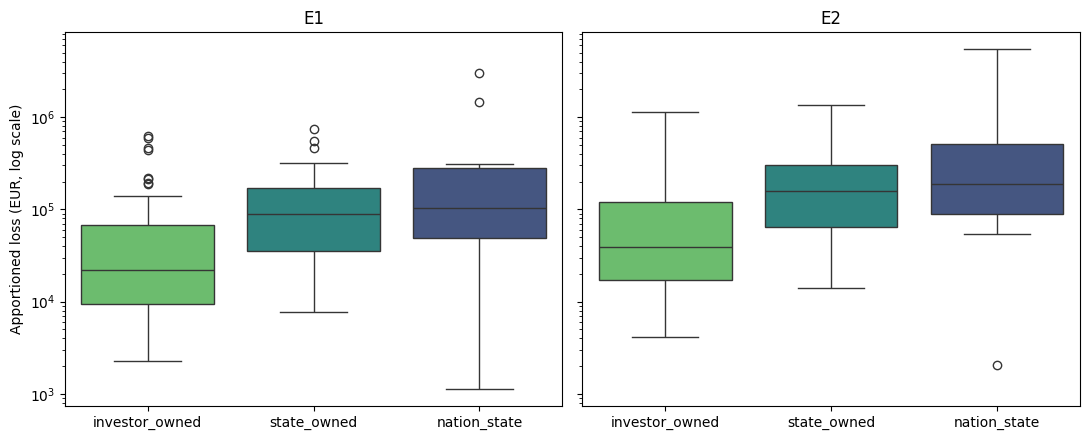

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, eid in zip(axes, ["E1", "E2"]):
    sub = df[df.event_id == eid]
    sns.boxplot(x="entity_type", y="loss_eur_central", data=sub, ax=ax,
                order=["investor_owned", "state_owned", "nation_state"],
                hue="entity_type", palette="viridis", legend=False)
    ax.set_yscale("log")
    ax.set_title(eid)
    ax.set_xlabel("")
    ax.set_ylabel("Apportioned loss (EUR, log scale)" if eid == "E1" else "")
plt.tight_layout()
plt.show()

**Result:** both tests are significant for both events (Kruskal-Wallis p < 0.001; nation-state vs investor-owned p = 0.004), consistent across E1 and E2.

**Caveat, stated plainly:** this project apportions each event's national loss to entities in fixed proportion to emissions share, so an entity's apportioned loss is a monotonic transform of its emissions share. That means this result is mathematically guaranteed to agree with a test run directly on emissions share — it is not an independent empirical discovery about losses, it is a structural consequence of the apportionment method. It's still worth reporting, because it correctly answers the report's stated hypothesis (about losses, not emissions) and confirms entity type is doing real work in the loss ranking, but it should not be oversold as new information beyond what Section 2.1's emissions breakdown already implies.

## H2 — Event differences (E1 vs E2)

**H0:** E1 and E2 loss distributions are the same.
**H1:** they differ.

The same 122 entities appear in both events, so this is a **paired** comparison — Wilcoxon signed-rank, not the independent-samples Mann-Whitney used for H1.

In [4]:
e1 = df[df.event_id == "E1"].set_index("entity")["loss_eur_central"]
e2 = df[df.event_id == "E2"].set_index("entity")["loss_eur_central"]
e1, e2 = e1.align(e2)

stat, p = wilcoxon(e1, e2)
ratio = e2 / e1

print(f"Wilcoxon signed-rank: W={stat:.2f}, p={p:.2e}")
print(f"E2/E1 loss ratio per entity: mean={ratio.mean():.3f}, std={ratio.std():.2e}")

Wilcoxon signed-rank: W=0.00, p=9.24e-22
E2/E1 loss ratio per entity: mean=1.812, std=3.29e-16


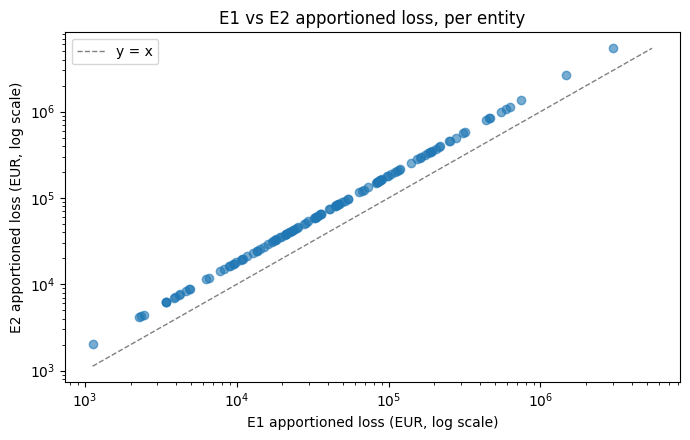

In [5]:
plt.figure(figsize=(7, 4.5))
plt.scatter(e1, e2, alpha=0.6)
lims = [min(e1.min(), e2.min()), max(e1.max(), e2.max())]
plt.plot(lims, lims, "--", color="grey", linewidth=1, label="y = x")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("E1 apportioned loss (EUR, log scale)")
plt.ylabel("E2 apportioned loss (EUR, log scale)")
plt.title("E1 vs E2 apportioned loss, per entity")
plt.legend()
plt.tight_layout()
plt.show()

**Result:** the difference is significant (p < 0.001) and, looking at the ratio, mechanical rather than incidental — every entity's E2 loss is almost exactly 1.81x its E1 loss (std of the ratio is ~0, visible above as points falling on a single line parallel to y = x on the log-log plot). This is expected by construction: E2's longer duration (12 vs 3 days) and slightly higher GDP base year produce one national-level scaling factor that's applied identically to every entity, since apportionment shares don't change between events. The test formally confirms the duration-driven gap already described narratively in Report Section 3.2 — it does not add a new mechanism, but it does verify that the qualitative claim ("every E2 bar sits to the right of its E1 counterpart") holds with statistical backing rather than just visual inspection.

## Bootstrap confidence intervals by entity type

The original draft of this analysis bootstrapped a CI for nation-state entities alone, which doesn't support a comparison. Here we compute 95% bootstrap CIs for the mean **total** apportioned loss per entity (summed across E1 + E2, matching the definition used in Report Figure 3) for all three entity types, so the comparison in Section 3.3 has interval estimates behind it.

In [6]:
def bootstrap_mean_ci(data, n_bootstraps=2000, confidence_level=0.95, seed=42):
    rng = np.random.default_rng(seed)
    boots = [rng.choice(data, size=len(data), replace=True).mean() for _ in range(n_bootstraps)]
    lo = np.percentile(boots, (1 - confidence_level) / 2 * 100)
    hi = np.percentile(boots, (1 + confidence_level) / 2 * 100)
    return np.mean(data), lo, hi

pivot = df.pivot_table(index=["entity", "entity_type"], columns="event_id", values="loss_eur_central").reset_index()
pivot["total_central"] = pivot["E1"] + pivot["E2"]

results = []
for t in ["investor_owned", "state_owned", "nation_state"]:
    vals = pivot.loc[pivot.entity_type == t, "total_central"].values
    mean, lo, hi = bootstrap_mean_ci(vals)
    results.append({"entity_type": t, "n": len(vals), "mean_eur": mean, "ci_low": lo, "ci_high": hi})

ci_table = pd.DataFrame(results)
ci_table

,entity_type,n,mean_eur,ci_low,ci_high
0,investor_owned,76,1.870048e+05,118356.963825,2.735011e+05
1,state_owned,35,3.810513e+05,249459.597255,5.474706e+05
2,nation_state,11,1.428781e+06,291113.716738,3.180719e+06


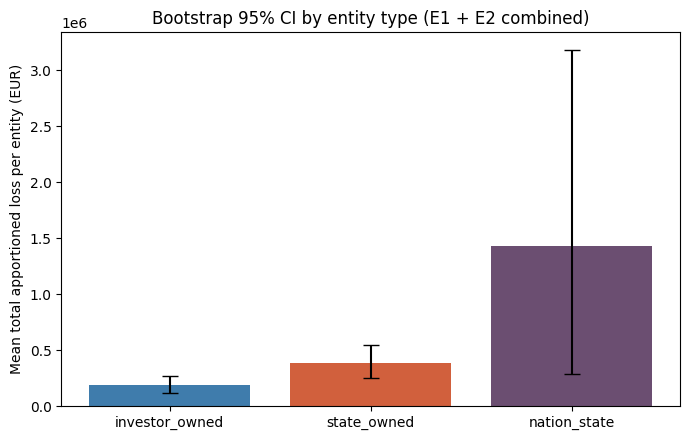

In [7]:
plt.figure(figsize=(7, 4.5))
x = np.arange(len(ci_table))
means = ci_table["mean_eur"]
err_low = means - ci_table["ci_low"]
err_high = ci_table["ci_high"] - means
plt.bar(x, means, yerr=[err_low, err_high], capsize=6, color=["#3F7CAC", "#D1603D", "#6B4E71"])
plt.xticks(x, ci_table["entity_type"])
plt.ylabel("Mean total apportioned loss per entity (EUR)")
plt.title("Bootstrap 95% CI by entity type (E1 + E2 combined)")
plt.tight_layout()
plt.show()

**Result:** nation-state entities have the highest mean per-entity loss (~EUR 1.43M, CI ~291k-3.18M), driven by a small number of very large emitters (China (Coal), Former Soviet Union). Its CI does not overlap with investor-owned (~EUR 187k, CI 118k-274k), giving a defensible claim that nation-state entities carry a higher per-entity burden than investor-owned ones. It does overlap with state-owned (~EUR 381k, CI 249k-547k), so that contrast is not statistically distinguishable at this sample size. This directly supports — with interval estimates rather than just summed totals — the Report Section 3.3 argument that nation-state producers are not a negligible part of the liability picture.

## Summary

- Entity type is associated with apportioned loss (H1), but this follows mechanically from the fixed emissions-share apportionment rather than being an independent finding about losses.
- E2 (July 2022) losses exceed E1 (April 2023) losses for every entity by a near-constant ~1.81x factor (H2), confirming the duration-driven gap described in Report Section 3.2.
- Nation-state entities have a credibly higher mean per-entity loss than investor-owned entities (non-overlapping 95% CIs); the nation-state vs. state-owned contrast is not statistically distinguishable at this sample size.